## Feature Selection 
Extracting important features from given features . 

### It is a technique to standardize the independent features present in the data in a fixed range .

lets say we have x=age/y=salary/purchase columns and we are solving knn problems in which it calculates distance between two points Euclindean Distance between P1 and P2 = sqrt((x2 - x1)^2 + (y2 - y1)^2). our scale of age is in tens and salary in thousand so when knn will calculate distance it will be to large for p1 and p2 small.
 

## Types of Feature Scaling 
#### Standardization Also called as Z-score Normalization
#### Normalization - Robust scaler MinMaxscaler 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [49]:
df = pd.read_csv(r"C:\Users\karth\Downloads\Social_Network_Ads.csv")

In [50]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [51]:
# Keeping only columns that we need
df=df.iloc[:,2:]

In [5]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [6]:
df.sample(5)

,Age,EstimatedSalary,Purchased
391,47,23000,1
236,40,57000,0
205,47,47000,0
302,37,137000,1
375,46,32000,1


In [7]:
# To perform Feature scaling first we need to do train test split highly recommended .

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

X_train.shape , X_test.shape

((280, 2), (120, 2))

## StandardScaler 

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#To fit scaler to the train set , it will learn the parameters(mean and std dev of features in this case age and salary)
# It will calculate the mean and standard deviation of the train dataset for each feature 
scaler.fit(X_train)

#Transform train and test sets 
# We make scaler function learn about parameters from only train dataset but we transform both test and train data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
#Before transformation mean of age is 3.7 and mean of salary is 6.9
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [11]:
# std dev of the age and salary
scaler.scale_

array([1.01999375e+01, 3.45792870e+04])

In [12]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [13]:
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [14]:
# After transforming we get numpy array of scaled dataset so just to visualize converting to pandas dataframe 
X_train_scaled = pd.DataFrame(X_train_scaled,columns= X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns= X_test.columns)

In [15]:
# round off decimels to 1 (.0)
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [16]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


### Effect of Scaling 

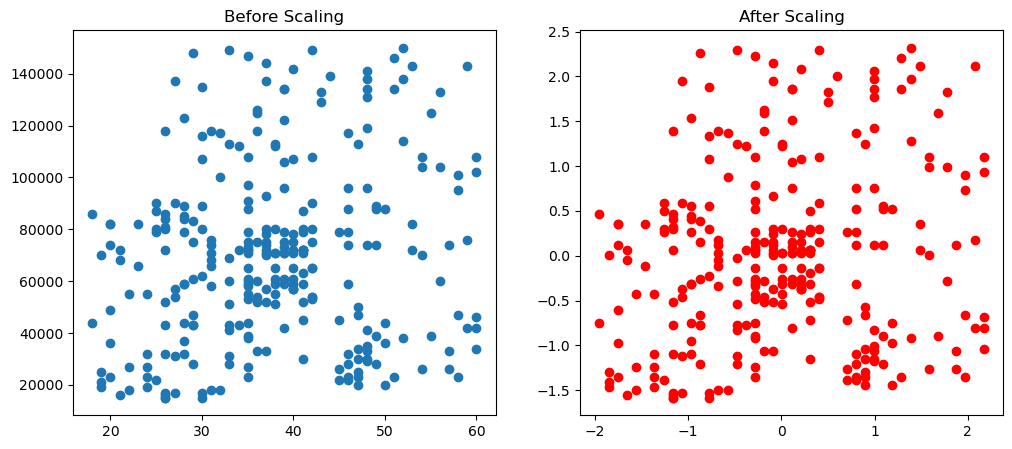

In [17]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title('After Scaling')
plt.show()

Shape of the data is same but scale has changed.Mean centering and restricting std dev has happend after standardization but the data shape is same 

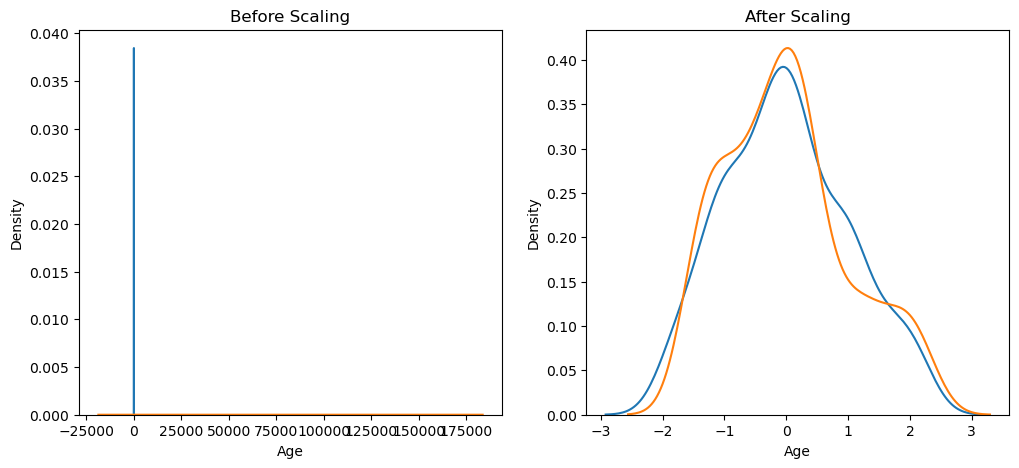

In [18]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# Before Scaling 
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
ax1.set_title("Before Scaling")

# After Scaling
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
ax2.set_title('After Scaling')
plt.show()

When we plot pdf of before scaling and after scaling we can see clearly that the age and salary are non comparable before scaling due to differences in their scales.Age is in a very small range that is why curve peaked to high whereas salary is to spread into huge area that is why curve is flat.

<Axes: title={'center': 'Age Distribution After Standard Scaling'}, xlabel='Age', ylabel='Density'>

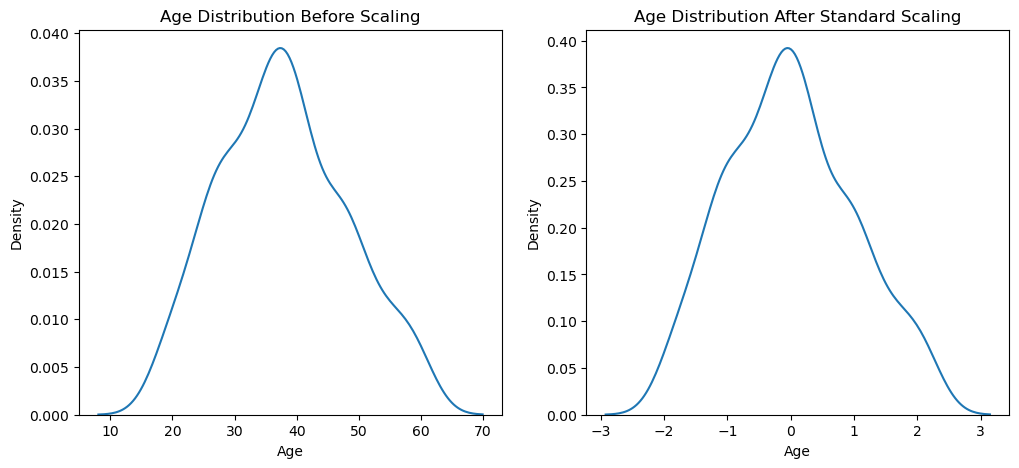

In [19]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# Before Scaling 
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'],ax=ax1)

# After Scaling 
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)

In [20]:
df.columns 

Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object')

<Axes: title={'center': 'Age Distribution After Standard Scaling'}, xlabel='EstimatedSalary', ylabel='Density'>

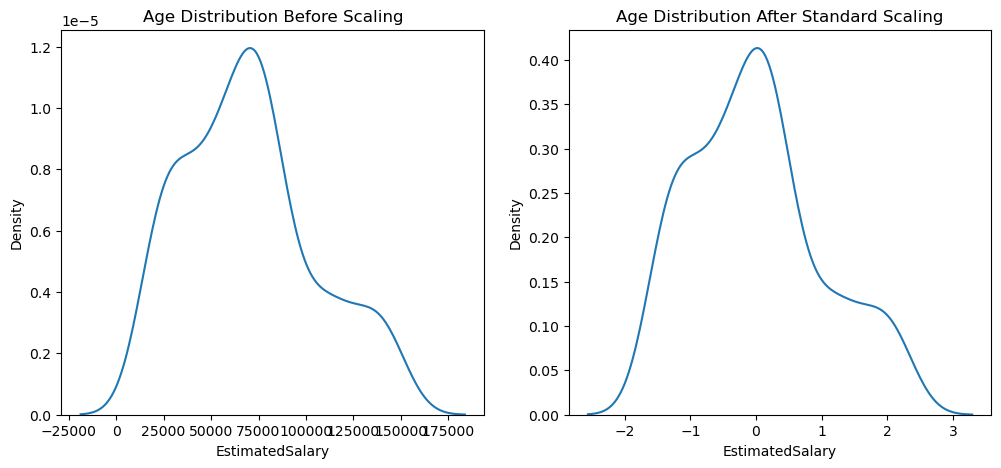

In [21]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# Before Scaling 
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# After Scaling 
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

#### Shape of the distribution remains same after applying standardization what changes is that mean centering equal to zero and standard deviation equals to 1.

In [23]:
# Why scaling is important 

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [24]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [25]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.6583333333333333
Scaled 0.8666666666666667


In [28]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [31]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [32]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [33]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


Logistic Regression is a algorithm that needs your data to be scaled and it performs well with scaled data .we can see difference in the accuracy score result before and after scaling . But at the same time decisiontree classifier is an algorithm with has nothing to do with scaling it gives almost same result with scaled dataset or unscaled dataset.

In [34]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


## Effect of Outlier 

In [52]:
#Deliberately putting outliers in the dataset to see the effect
df = pd.concat([df,
               pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})]
               ,ignore_index=True)

In [53]:
df.tail()

,Age,EstimatedSalary,Purchased
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1
402,95,350000,1


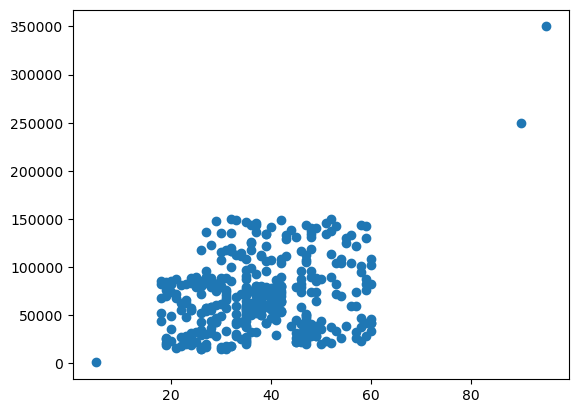

In [55]:
plt.scatter(df['Age'],df['EstimatedSalary'])

In [56]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

X_train.shape , X_test.shape

((282, 2), (121, 2))

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled =scaler.transform(X_test)

In [58]:
# After transforming we get numpy array of scaled dataset so just to visualize converting to pandas dataframe 
X_train_scaled = pd.DataFrame(X_train_scaled,columns= X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns= X_test.columns)

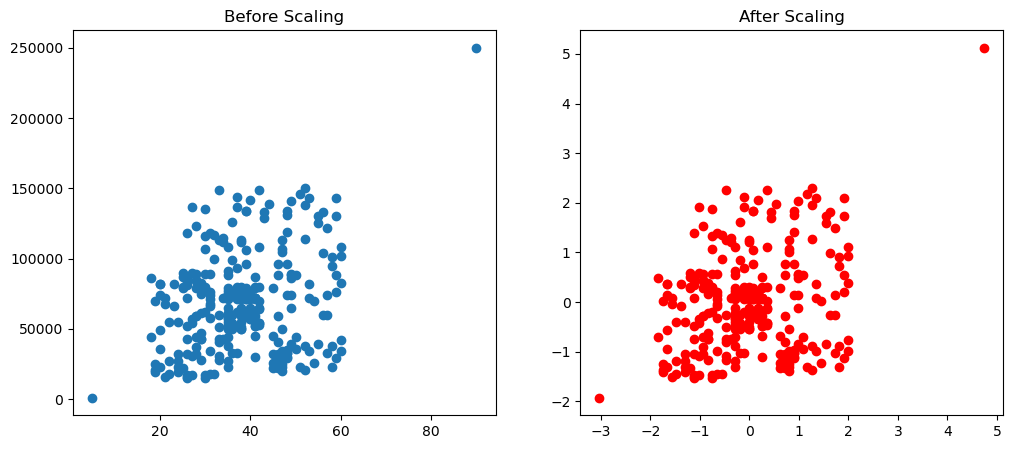

In [59]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title('After Scaling')
plt.show()

#### When to use standardization : there is no negative impact of standardization and it does not handle outlier and it treat outlier as it is .

### Algorithm           : reason for applying feature scaling
1. K - means algorithm :  Use the euclidean distance measure
2. K-Nearest Neighbours : Measures the distance between pairs of samples and these distance are influenced by the measurement units 
3. Principal component analysis : try to get the feature with maximum variance
4. Artifical Neural Network: Apply gradient descent 
5. Gradient Descent : Theta calculation becomes faster after feature scaling and the learning rate in the update equation of stochastic gradient descent is the same for every parameter 

## Feature Scaling Normalization

Normalization is a techique often applied as part of data preparation for machine learning. The goal of normalization is to change the values of numeric columns in the dataset to use a common scale,without distorting difference in the ranges of values or losing information.

Types of Normalization 

1. MinMaxScaling 
2. Mean Normalization 
3. Max absolute Scaling
4. Robust Scaling 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv(r"C:\Users\karth\Downloads\wine_data.csv",header=None,usecols=[0,1,2])
df.columns = ['Class label','Alcohol','Malic acid']

In [10]:
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

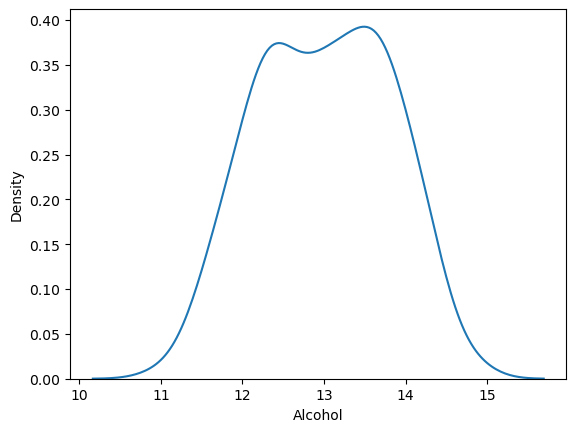

In [11]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

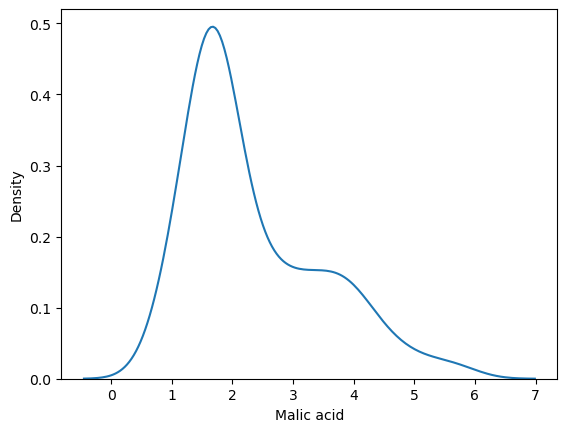

In [12]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

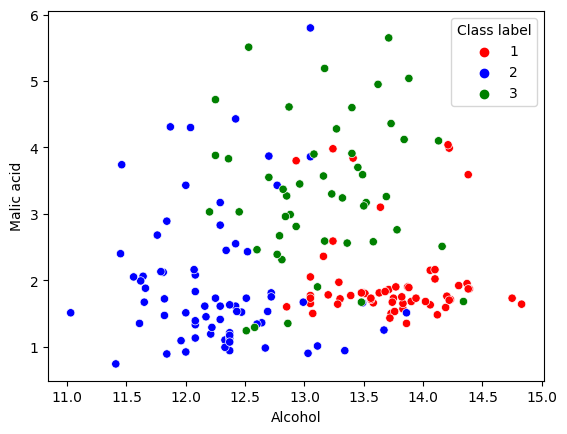

In [16]:
color_dict = {1:'red',3:'green',2:'blue'}
sns.scatterplot(data=df,x = df['Alcohol'],y=df['Malic acid'],hue=df['Class label'],palette=color_dict)

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Class label',axis=1),df['Class label'],test_size=0.3,random_state=0)

X_train.shape , X_test.shape

((124, 2), (54, 2))

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled =scaler.transform(X_test)

In [19]:
# After transforming we get numpy array of scaled dataset so just to visualize converting to pandas dataframe 
X_train_scaled = pd.DataFrame(X_train_scaled,columns= X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns= X_test.columns)

In [20]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [22]:
np.round(X_train_scaled.describe(),1)

## After applying minmax scaler minimum value becomes 0 and maximum value becomes 1 as minmaxscaler distbn value range from 0 to 1.
 

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


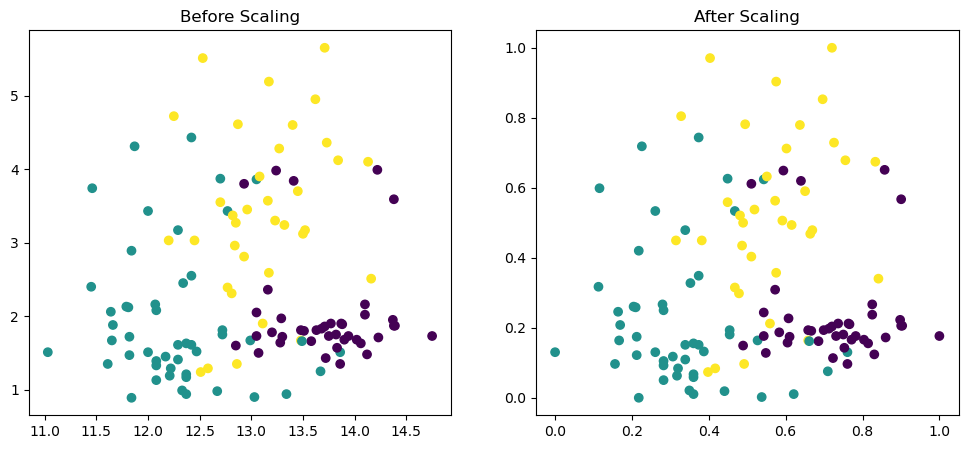

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()


Scale has changed but no difference in the shape of data. Normalization has squeezed data into unit rectangle as 2d ,and in 3d it will squeeze in cuboid and more than 3d it will squeeze or expand in hyper palne unit

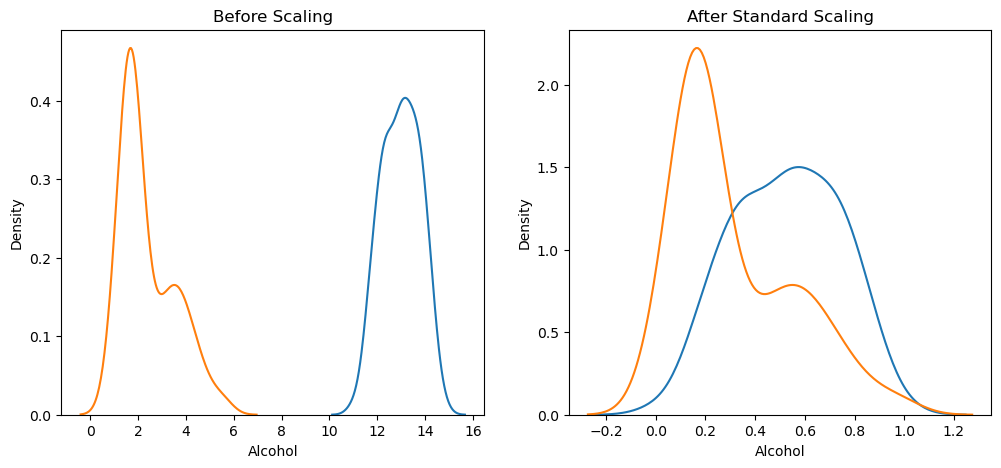

In [24]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

After applying minmax scale we can see scale of both the feature has become same btwn 0-1 . negative is due to kdeplot as it takes inference but that is not a problem over here .

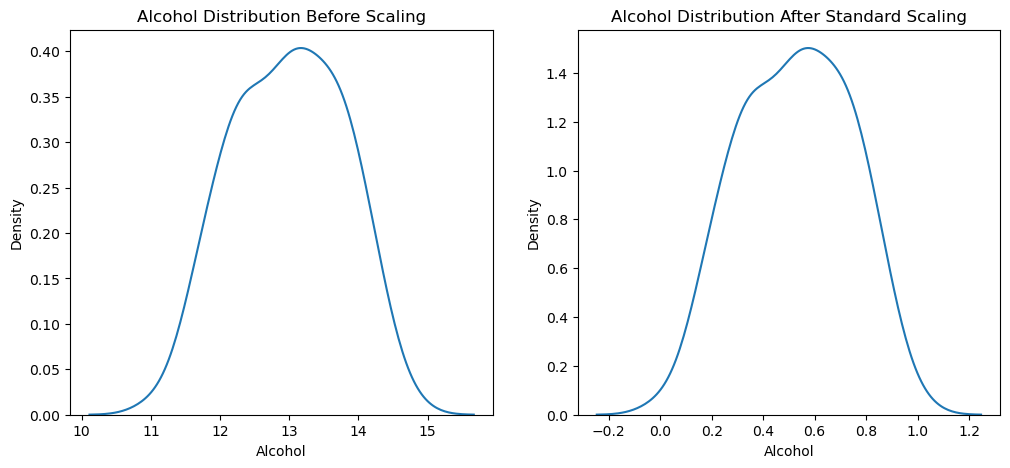

In [25]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

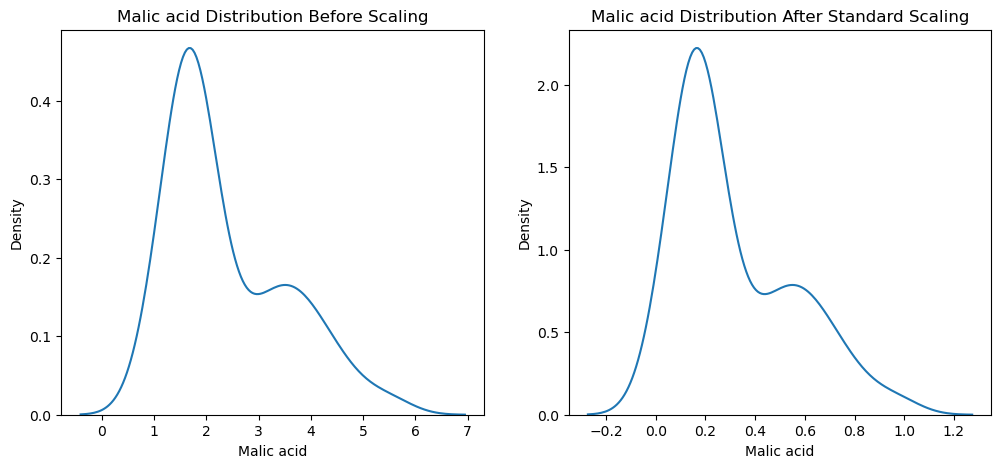

In [26]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

Shape may change not necessary that shape remains as it is .Also the outlier is also squeezed which is the only problem